Accuracy del modello: 0.90
Intercetta (beta_0): -3.26
Intercetta (beta_1): 0.82


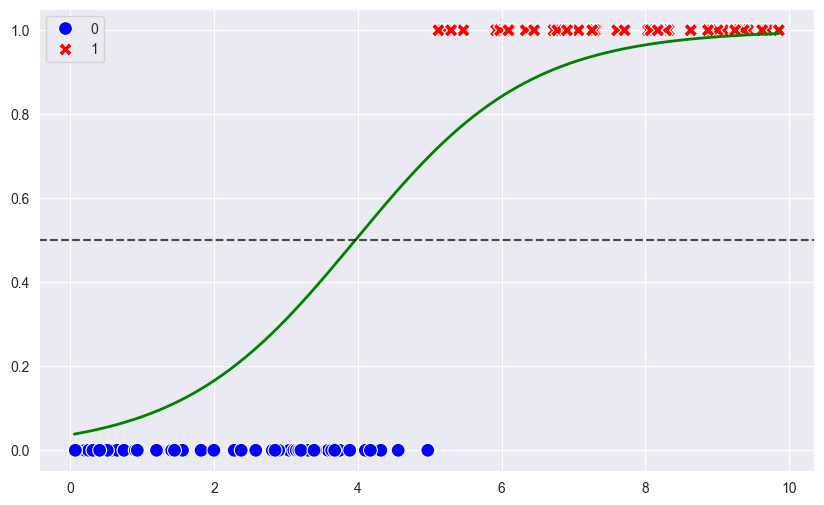

In [5]:
from pyexpat import model

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# Aggiunta delle librerie per il grafico
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creazione di Dati sintetici per classificazione binaria
np.random.seed(42)

# Una volta generati i dati li suddividiamo in training e test set
# Generiamo due predittori X (feature)
X = np.random.rand(100, 2)*10

# Y è la classe (0 o 1), basata su una semplice soglia di separazione lineare
# Usiamo solo una dimensione (x[:.0]) per poter visualizzare chiaramente la curva logistica
X_single = X[:,0].reshape(-1, 1) # Usiamo solo la prima colonna come predittore
y = (X_single.flatten() > 5).astype(int)

# 2. Suddivisione in Set di Addestramento e test set
X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.3, random_state=42)

# 3. Inizializzazione e Addestramento del modello
model  = LogisticRegression(solver='liblinear',random_state=42)
model.fit(X_train, y_train)

# 4. Previsioni e Valutazione
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modello: {accuracy:.2f}")

# 5. Interpretazione dei Coefficienti
print(f"Intercetta (beta_0): {model.intercept_[0]:.2f}")
print(f"Intercetta (beta_1): {model.coef_[0][0]:.2f}")

# 6. Visualizzazione della curva logistica

# Calcolo delle probabilità del modello su un intervallo continuo di valori X
X_range = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1, 1)
y_proba = model.predict_proba(X_range)[:, 1] # Prende la probabilità della classe 1

# Disegno dello scatter plot dei dati reali
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_single.flatten(), y=y, hue=y, palette={0: 'blue', 1: 'red'}, style=y, markers=['o', 'X'], s=100 )

# Disegno della curva di probabilità logistica
plt.plot(X_range, y_proba, color='green', linewidth=2, label='Curva Logistica $P(Y=1|X)$')

# Disegno della linea di soglia di decisione (0.5) e della linea X di separazione
plt.axhline(0.5, color='black', linestyle='--', alpha=0.7, label='Soglia di Decisione (0.5)')


